# **CrSBr Example**
### Calculating reflection and transmission of a patterned CrSBr flake. Powered by [$S^4$](https://web.stanford.edu/group/fan/S4/). Credit due to Victor Liu (Fan Group, Stanford Electrical Engineering Department, 2012).

#### This notebook version written by Ezra Bader (Menon Group / LaNMP, CCNY, May 2026) with help from Dr. Claude (Anthropic).

<div style="display: flex; justify-content: left; align-items: center; gap: 20px;">

<!-- <img src="https://web.stanford.edu/group/fan/S4/_images/schem_640.png" alt="schematic" width="400" style="border: 5px solid maroon;"> -->

<img src="crsbrHoleImage.png" alt="crsbr" width="700" style="border: 5px solid maroon;">

</div>

<span style="font-size:30px;">**Workflow:**</span>

<span style="font-size:20px;">**1.** Imports</span>

<span style="font-size:20px;">**2.** Lattice & layers</span>

<span style="font-size:20px;">**3.** Configure parameters</span>

<span style="font-size:20px;">**4.** Verify/plot unit cell, refractive index</span>

<span style="font-size:20px;">**5.** Convergence and spot tests</span>

<span style="font-size:20px;">**6.** Run studies or load data</span>

<span style="font-size:17px;"> &emsp; 6.0.1 — Quick checks, run study 0 (reflection)</span>

<span style="font-size:17px;"> &emsp; 6.1.1 — Run study 1 (E vs. k)</span>

<span style="font-size:17px;"> &emsp; 6.2.1 — Run study 2 (kx, ky)</span>

<span style="font-size:17px;"> &emsp; 6.3.1 — Run study 3 (mode calculation)</span>

<span style="font-size:20px;">**7.** Plotting</span>

<span style="font-size:20px;">**8.** Examples</span>

### Under construction --

<span style="font-size:20px;">**??.** GUI

<span style="font-size:20px;">**??.** Polarization vortex analysis


-------------------
# **Requirements**
### All standard python libraries will import automatically. If a library is not found, you probably haven't installed it in your environment. If you are using a conda environment, for example, and \<library-name\> is not found, you'll run the following in your command line:

```bash
conda activate <your-env-name>
conda install <library-name>
```

### Slightly more complicated is S4, which should be built from the source code. Unix-like environment and C++ compiler required—on Windows, you'll have to use something like WSL (Windows Subsystem for Linux). Then in the terminal:

```bash
cd ~/your-project-folder
git clone https://github.com/victorliu/S4.git
```

### Nothing else is technically required, but [the authors recommend](https://web.stanford.edu/group/fan/S4/install.html) certain additional packages. Once you've flagged these in your Makefile:

```bash
make lib
make S4_pyext
```

# **1. Imports**

In [44]:
import rcwa_utils as ru     # NOTE: Imports all the necessary helper functions to run this notebook.
from rcwa_utils import *    
import S4                   # NOTE: Your python environment must have a valid S4 installation
import numpy as np
import pandas as pd
from abc import ABC, abstractmethod
import threading
import time, warnings, itertools
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from scipy.interpolate import interp1d, griddata
from pathlib import Path
from joblib import Parallel, delayed
import re as _re
from datetime import datetime as _dt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from scipy.interpolate import griddata
import tkinter as tk
from tkinter import filedialog
import tempfile
import os
import shutil
import importlib
from dataclasses import dataclass, field
importlib.reload(ru)

MATERIALS = ru.load_material_library()

Material library loaded. Currently supported materials:
Air, Si, SiO2, TiO2, SiN, CrSBr, MoOCl2, ReS2, LC


# **2. Layers**

For each layer specify a <span style="color:#9CDCFE">**MATERIAL**</span> and <span style="color:#9CDCFE">**THICKNESS**</span> (nm). Lattice constant will be set in the next cell.

Optional arguments:

<span style="color:#9CDCFE">**PATTERN**</span>  — Currently supported: 'hole', 'pillar', 'cuboids'.

<span style="color:#9CDCFE">**ROT (°)**</span>      — Rotates permittivity tensor $\bm{\epsilon_{ij}}$ about $\bm{\hat{z}}$. 

```python
# EXAMPALE CALLS: 

MY_LAYERS1 = [
    ru.Layer('Air',    500,    pattern=None),
    ru.Layer('SiO2',   50,     pattern='hole', ff=0.5),
    ru.Layer('CrSBr',  70,     pattern='hole', ff=0.5, layer_rot=45),
    ru.Layer('Air',    500,    pattern=None)
]

MY_LAYERS2 = [
    ru.Layer('Air',    500,    pattern=None),
    ru.Layer('ReS2',   90,     pattern='cuboids', w0=250, alpha=0.6),
    ru.Layer('Air',    500,    pattern=None)
]
```

In [45]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║       LAYERS  (top to bottom; pick material, thickness in nm)            ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# NOTE: Stack is built top down, where the first layer starts at z=0 and ends at z=|layer_thickness|.
#       The "transmission" side will be the LAST layer in the following list.
#       Since RCWA is all plane waves, the actual orientation of your stack
#       shouldn't matter UNLESS your materials break reciprocity! Then you can no longer safely
#       exchange source & detector.

MY_LAYERS = [
    Layer('Air',    500,     pattern=None),
    Layer('SiO2',    50,     pattern='hole',  ff=0.5),
    Layer('CrSBr',  100,     pattern='hole', ff=0.5),
    Layer('SiO2',    90),
    Layer('Si', 100),
    Layer('Air',    500,     pattern=None)
]

# check_layers(layers=MY_LAYERS)

# **3. Configure Parameters**

In [47]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                          SWEEP CONFIG.                                   ║
# ╚══════════════════════════════════════════════════════════════════════════╝

conf = RCWAConfig(
    layers = MY_LAYERS,
    lattice_const = 500.0,
    lam_start = 885,
    lam_stop = 1030,
    lam_step = 4,
    n_basis = 25,
    n_grid = 10,
    n_jobs = 8,
    global_rot = 0,          # Global index tensor rotation around ẑ
    # save_to='default',
    save_to = '/Users/ezra/Desktop/LaNMP/python_scripts/RCWA/globalVersion/rcwa_output/CrSBrexample',

    # Defining study 1, E vs. k
    study1 = Study1Config(
        elev_max = 30.0,
        elev_n = 40,
        azim_vals = [0.0, 90.0]
    ),

    # Defining study 2, kx vs. ky
    study2 = Study2Config(
        elev_max = 40.0,
        elev_n = 40,
        azim_n_max = 180,
        azim_n_min = 45
    )
)

conf.verify_config()

layer   material    thickness (nm)        pattern                 rot (°) 
--------------------------------------------------------------------------
0       Air         500                   None                    0       
1       SiO2        50                    hole, ff=0.5            0       
2       CrSBr       100                   hole, ff=0.5            0       
3       SiO2        90                    None                    0       
4       Si          100                   None                    0       
5       Air         500                   None                    0       

Wavelengths: 885–1029 nm (37 pts)
Study 1: 40 elev × 2 azim = 80 pairs
Study 2: 3881 (azim, elev) pairs
Workers: 8  |  N_BASIS: 25

Output directory: /Users/ezra/Desktop/LaNMP/python_scripts/RCWA/globalVersion/rcwa_output/CrSBrexample


# **4. Unit Cell and Refractive Index Plots**

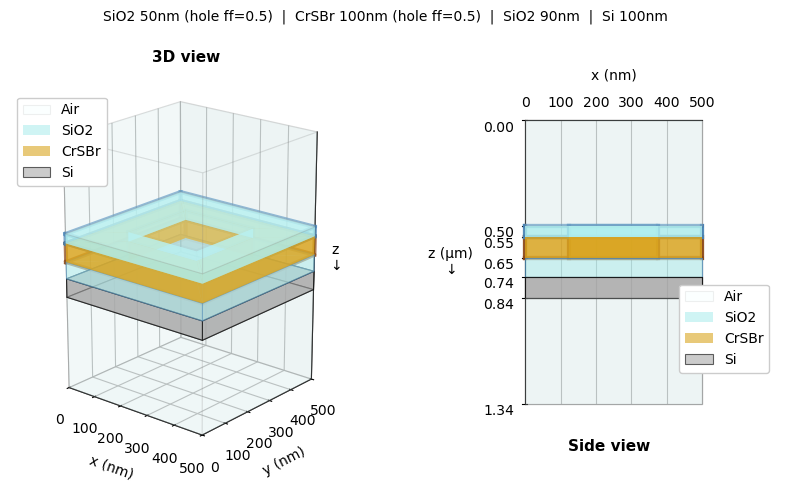

In [39]:
# indexplot = ru.plot_refractive_index(conf,layers=None,materials=None,lam_min=None,lam_max=None,n_pts=600)
# indexplot = ru.plot_refractive_index(conf, lam_min = 500, lam_max= 600)
unitcellplot = plot_unit_cell(conf, save_fig = False)

# **5. Convergence tests**

In [28]:
convergence_test(conf, basis_vals=(1, 4, 25, 49))
convergence_test_phase(conf, basis_vals=(1, 4, 25, 49))
scan_wavelengths(conf)
verify_energy_conservation(conf)

%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--
Convergence test: λ=950 nm  elev=5.0°  azim=0°  rot=0°
Stack: Layer(Air, 500.00nm) | Layer(SiO2, 50.00nm, hole, ff=0.5) | Layer(CrSBr, 100.00nm, hole, ff=0.5) | Layer(SiO2, 90.00nm) | Layer(Si, 100.00nm) | Layer(Air, 500.00nm)
|   NumBasis        T_ss        T_pp     |dT_ss|    time(ms)
|          1     0.16434     0.22222         nan        30.2
|          4     0.16434     0.22222     0.00000         0.4
|         25     0.11481     0.27154     0.04953        56.0
|         49     0.11475     0.28326     0.00006       282.9
%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--
Phase convergence: λ=950 nm  elev=5.0°  azim=0°    rot=0°  
|   NumBasis      |t_ss|    phase_ss (deg)          CD    time(ms)
|          1     0.33884           -49.676     0.00000        54.1
|          4     0.33884           -49.676     0.00000        50.8
|         25     0.33884 

# **7. Run Studies**

### **7.0.1 Quick Tests & Study 0 (reflection)**

In [29]:
qs1 = ru.quick_test_study1(conf)


Study 1: 8 pairs  |  8 workers
  P=500 nm  |  Air 500nm  |  SiO2 50nm (hole ff=0.5)  |  CrSBr 100nm (hole ff=0.5)  |  SiO2 90nm  |  Si 100nm  |  Air 500nm
  Study 1 [1/8  12%]  0.1 min elapsed,  ETC: 0.7 min  (5.6 s/task)
  Study 1 [2/8  25%]  0.1 min elapsed,  ETC: 0.3 min  (2.8 s/task)
  Study 1 [3/8  38%]  0.1 min elapsed,  ETC: 0.2 min  (1.9 s/task)
  Study 1 [4/8  50%]  0.1 min elapsed,  ETC: 0.1 min  (1.4 s/task)
  Study 1 [5/8  62%]  0.1 min elapsed,  ETC: 0.1 min  (1.1 s/task)
  Study 1 [6/8  75%]  0.1 min elapsed,  ETC: 0.0 min  (0.9 s/task)
  Study 1 [7/8  88%]  0.1 min elapsed,  ETC: 0.0 min  (0.8 s/task)
  Study 1 [8/8  100%]  0.1 min elapsed,  ETC: 0.0 min  (0.7 s/task)
Study 1 done in 0.1 min
%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--
/Users/ezra/Desktop/LaNMP/python_scripts/RCWA/globalVersion/rcwa_output/CrSBrexample
|
|
V
Config saved as study1_A500nm_SiO2-50nm-hole-ff0.5nm_CrSBr-100nm-hole-ff0.5nm_SiO2-90nm_Si-100nm_rot00

### **7.1.1 Study 1 (E vs. k)**

In [ ]:
df_s1 = run_study1(conf, print_every=32)


Study 1: 80 pairs  |  8 workers
  P=500 nm  |  Air 500nm  |  SiO2 50nm (hole ff=0.5)  |  CrSBr 100nm (hole ff=0.5)  |  SiO2 90nm  |  Si 100nm  |  Air 500nm
  Study 1 [32/80  40%]  0.4 min elapsed,  ETC: 0.6 min  (0.7 s/task)
  Study 1 [64/80  80%]  0.7 min elapsed,  ETC: 0.2 min  (0.7 s/task)
  Study 1 [80/80  100%]  0.9 min elapsed,  ETC: 0.0 min  (0.7 s/task)
Study 1 done in 0.9 min
%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--
/Users/ezra/Desktop/LaNMP/python_scripts/RCWA/globalVersion/rcwa_output/CrSBrexample
|
|
V
Config saved as study1_A500nm_SiO2-50nm-hole-ff0.5nm_CrSBr-100nm-hole-ff0.5nm_SiO2-90nm_Si-100nm_rot00_nb25_v4.json
Data saved as study1_A500nm_SiO2-50nm-hole-ff0.5nm_CrSBr-100nm-hole-ff0.5nm_SiO2-90nm_Si-100nm_rot00_nb25_v4.csv (2960 rows)


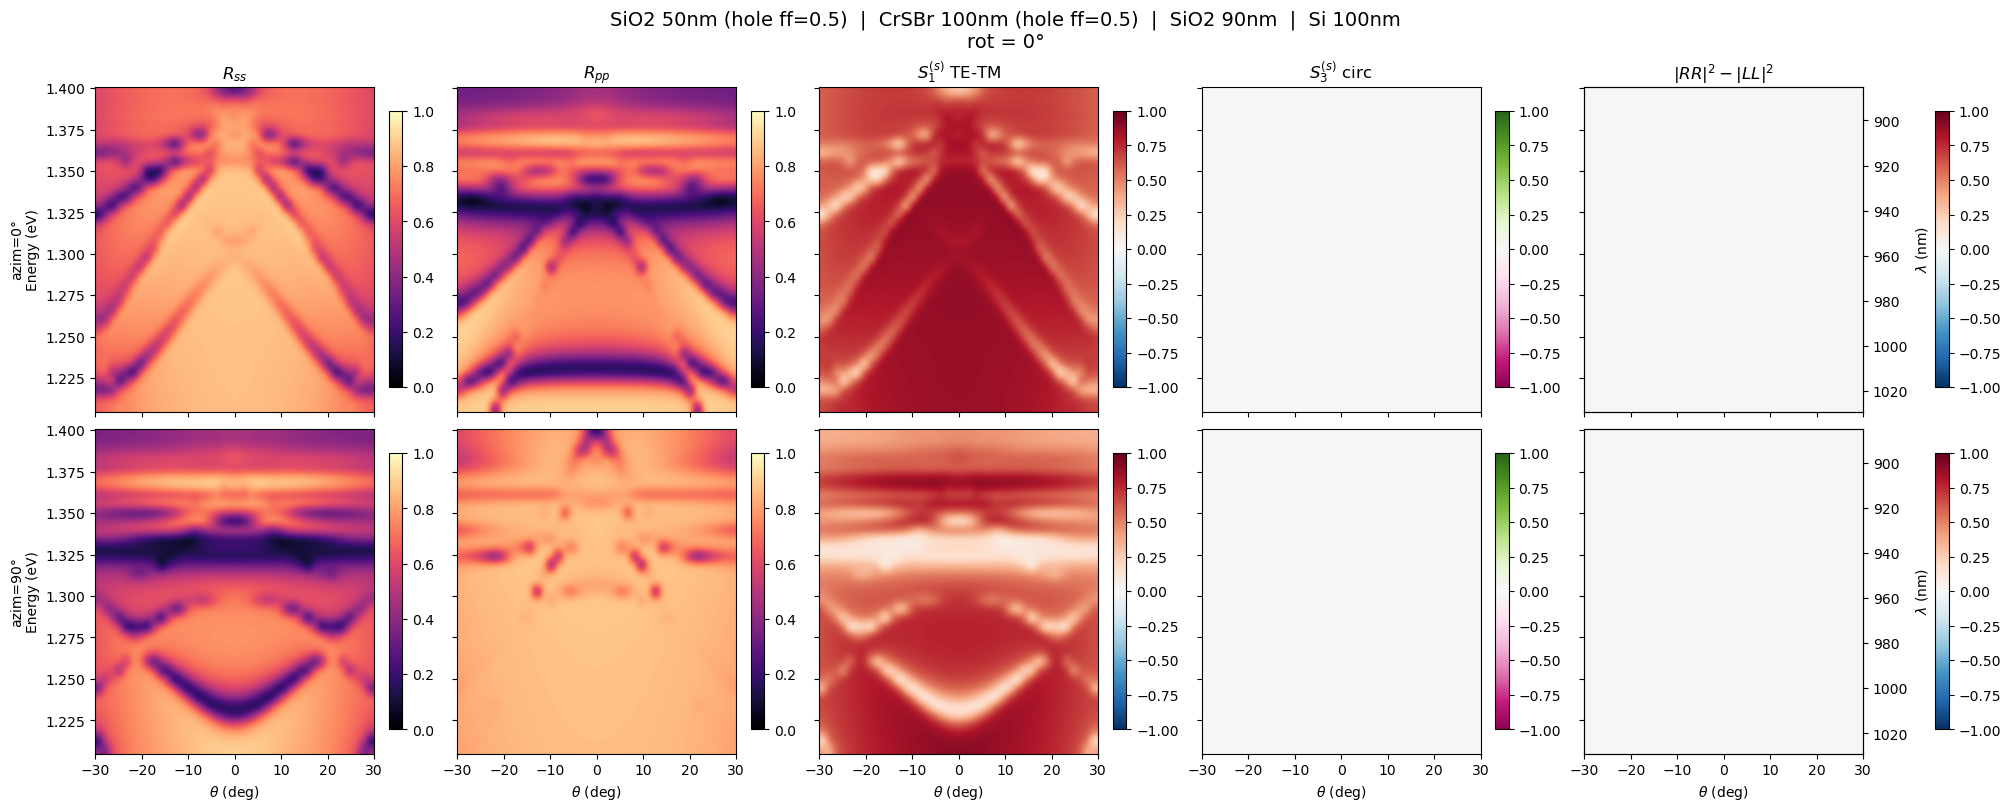

In [49]:
plot_crsbr_study1 = plot_study1(df_s1, conf, preset='crsbr')

### **7.2.1 Study 2 (kx vs. ky)**

In [ ]:
# df_study2 = run_study2(conf)

### **7.3.1 Study 3 (Modes)**

In [ ]:
# df_study3 = run_study3(conf)
# importlib.reload(ru)

<module 'rcwa_utils' from '/Users/ezra/gitprojects/rcwa-phc/rcwa_utils.py'>

### **7.4 Load Saved Data**

```python
ex_conf_loaded = ru.RCWAConfig.load('/Your_path_here.json')
```

In [247]:
# ── Load saved data with config ────────────────────────────────────────────────────────────
# NOTE: As of 2026 May 12, every study that gets run will automatically save with
# a config file of the same filename and extension .json. This config file
# contains all study parameters and must be recalled to plot the data.

df_load, conf_load = ru.load_study('/Users/ezra/Desktop/LaNMP/python_scripts/RCWA/globalVersion/rcwa_output/study1_A500nm_SiO2-50nm-hole-ff0.5_CrSBr-70nm-hole-ff0.5_SiO2-100nm_rot00_nb25.json')
conf_load.verify_config()


Loaded 128 rows  |  study1_A500nm_SiO2-50nm-hole-ff0.5_CrSBr-70nm-hole-ff0.5_SiO2-100nm_rot00_nb25.csv



TypeError: unsupported format string passed to NoneType.__format__

# **8. Plotting**

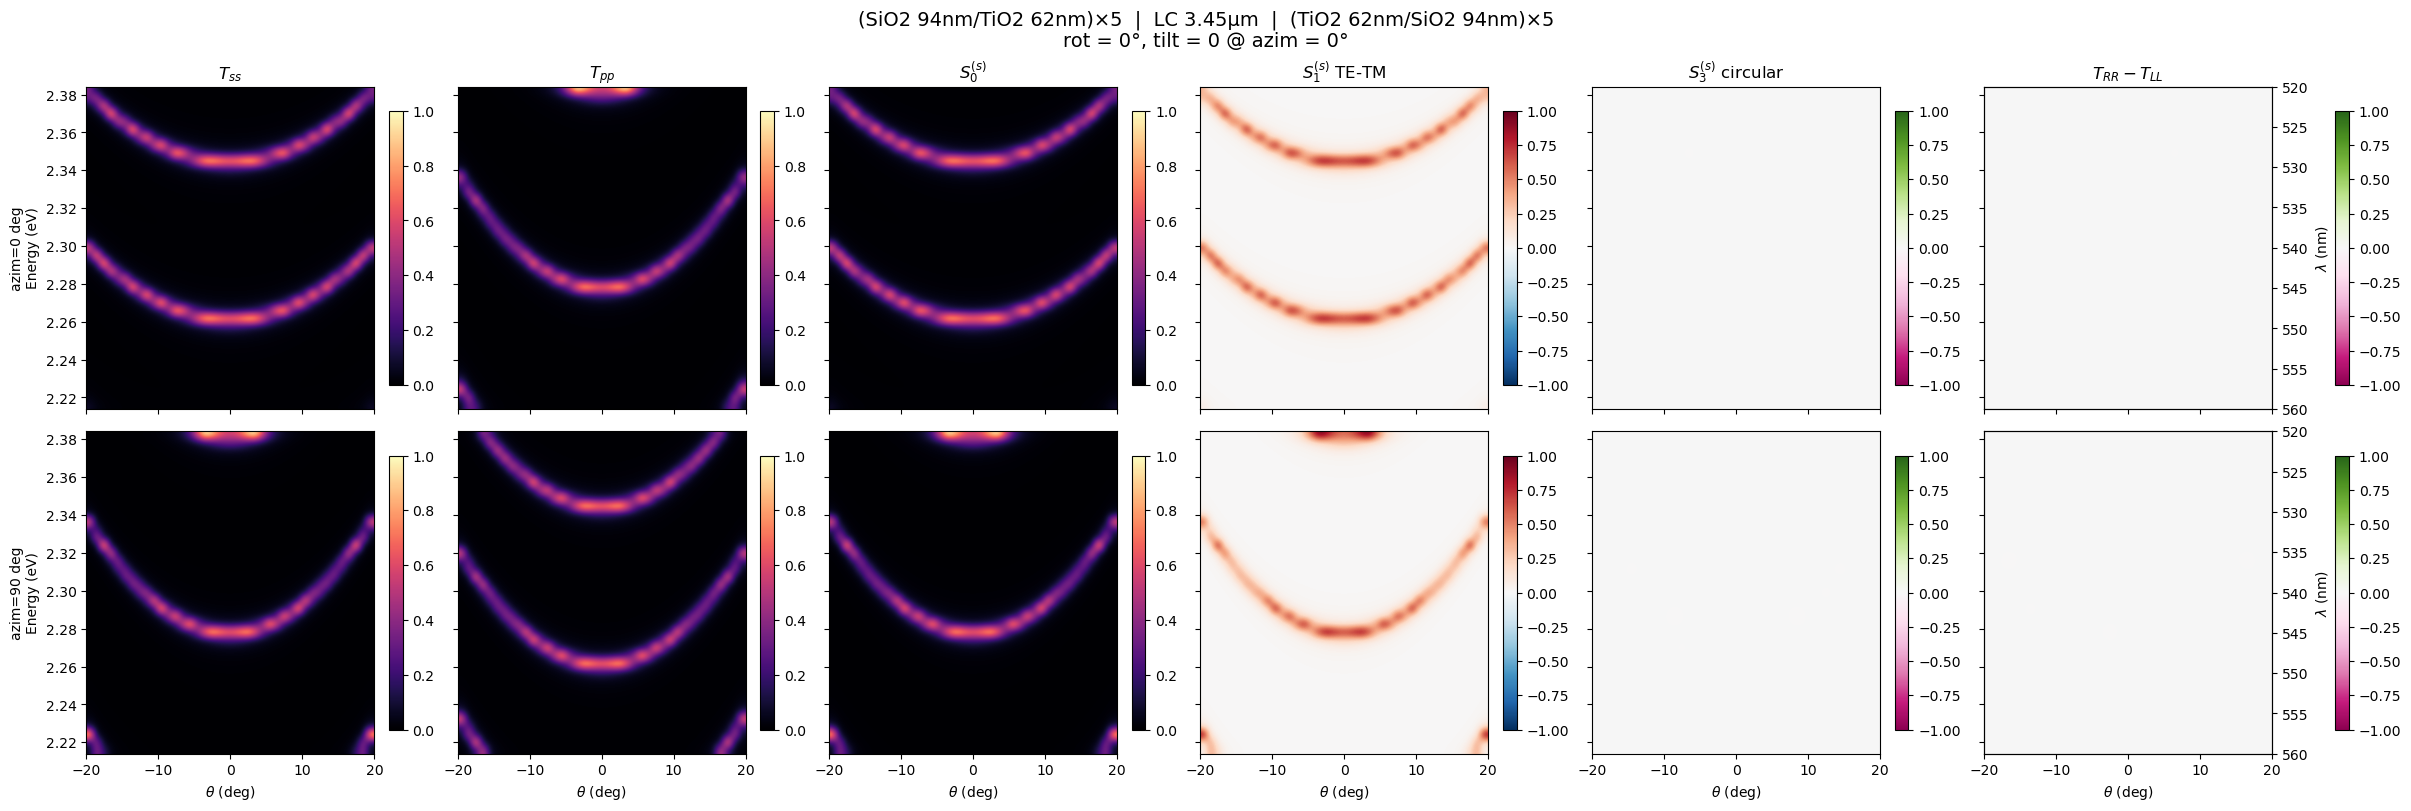

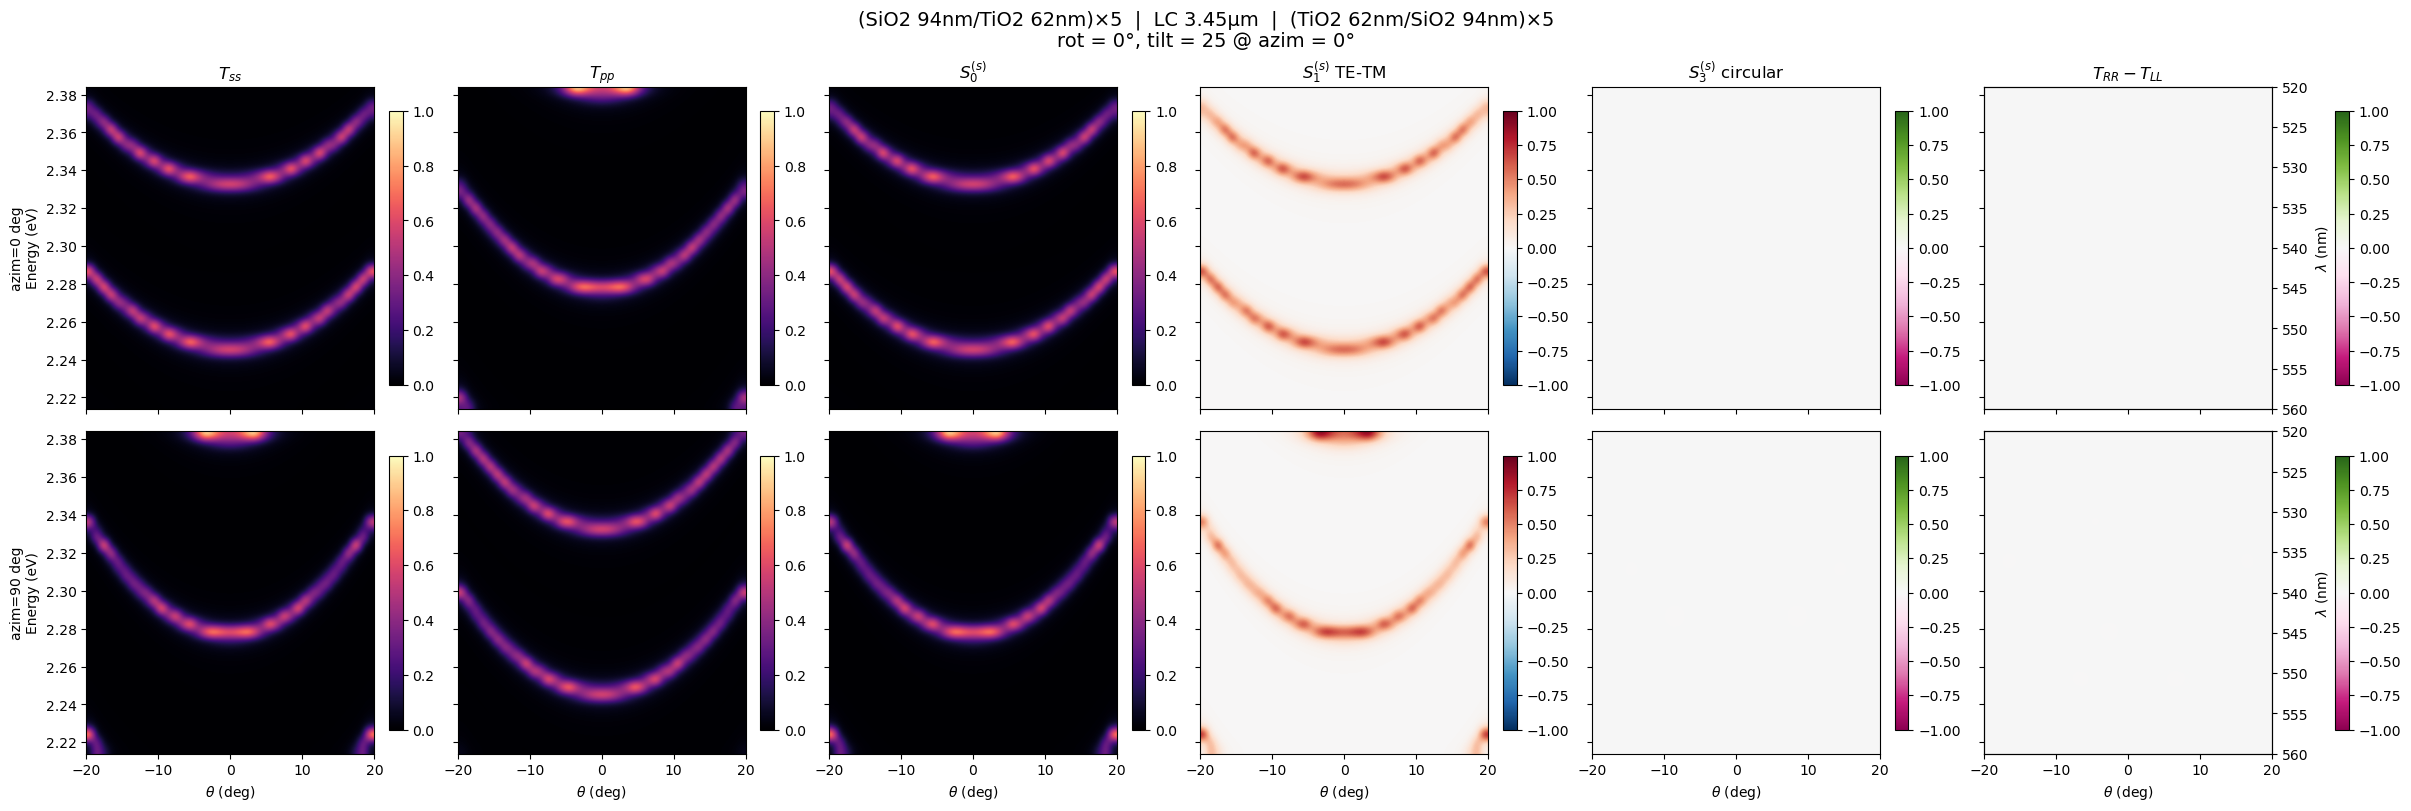

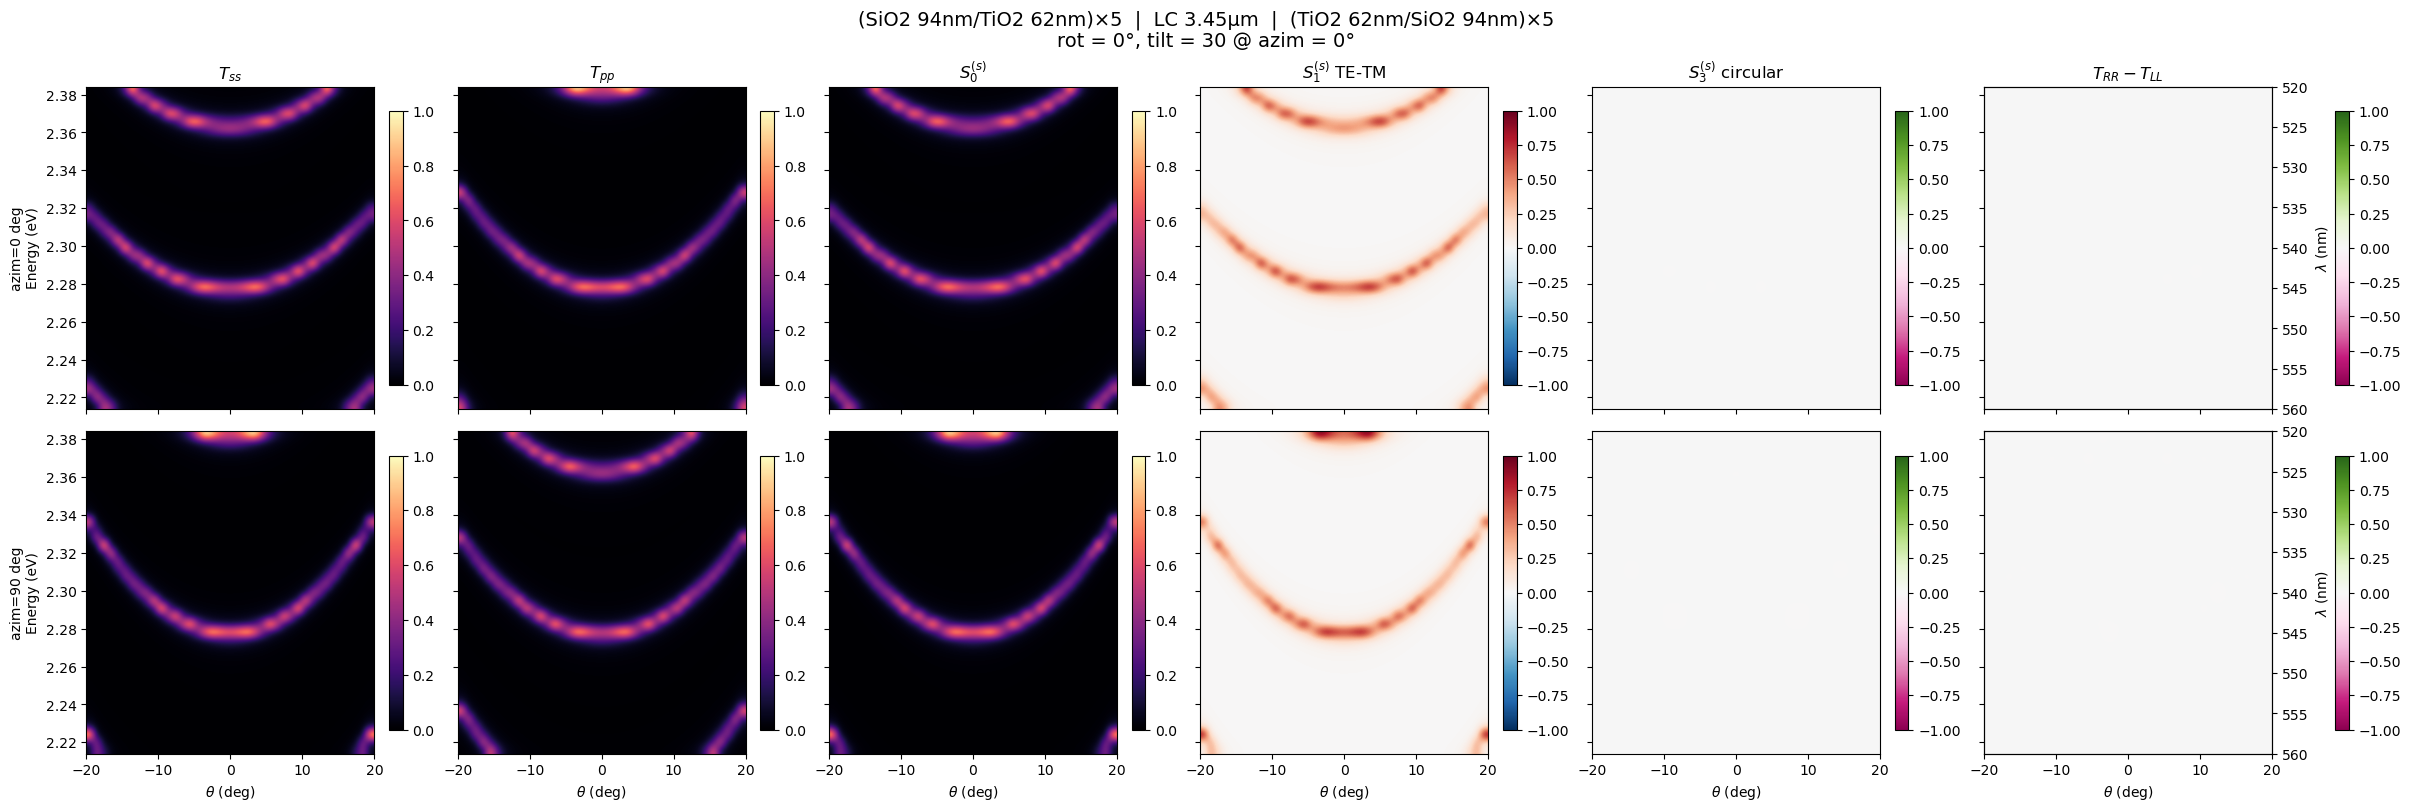

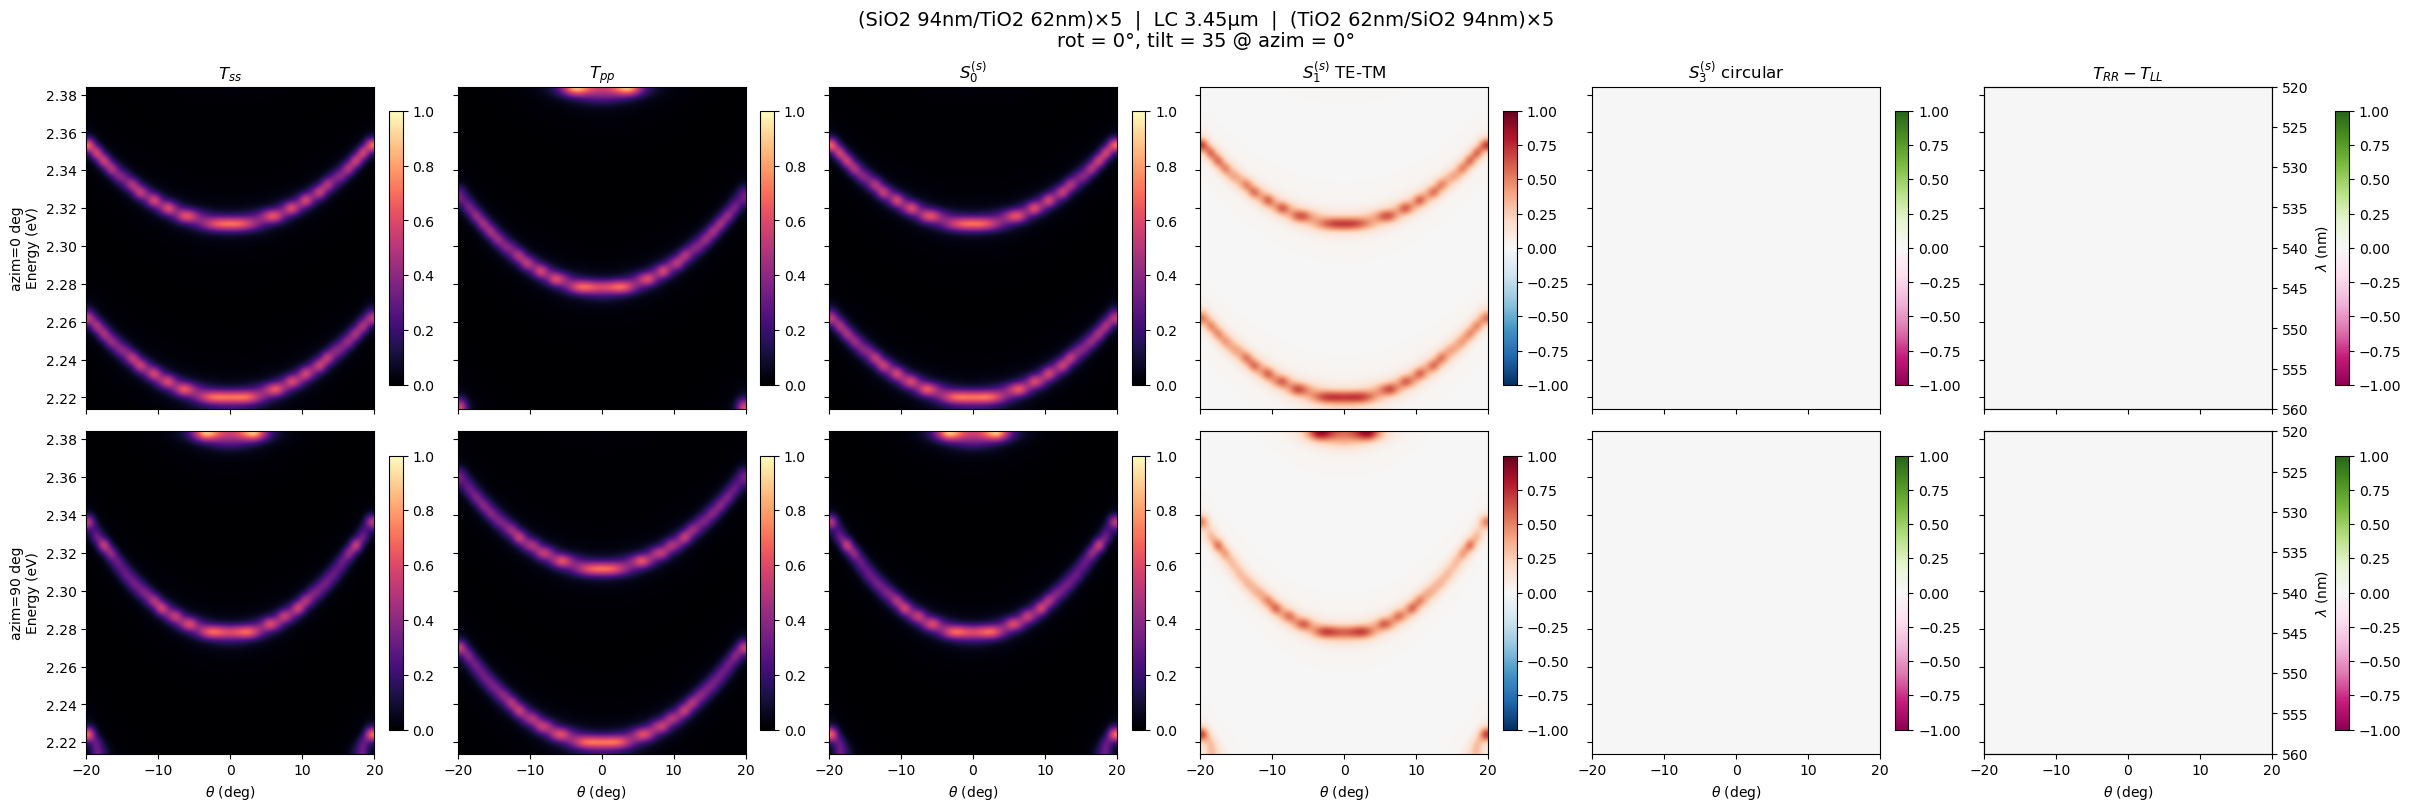

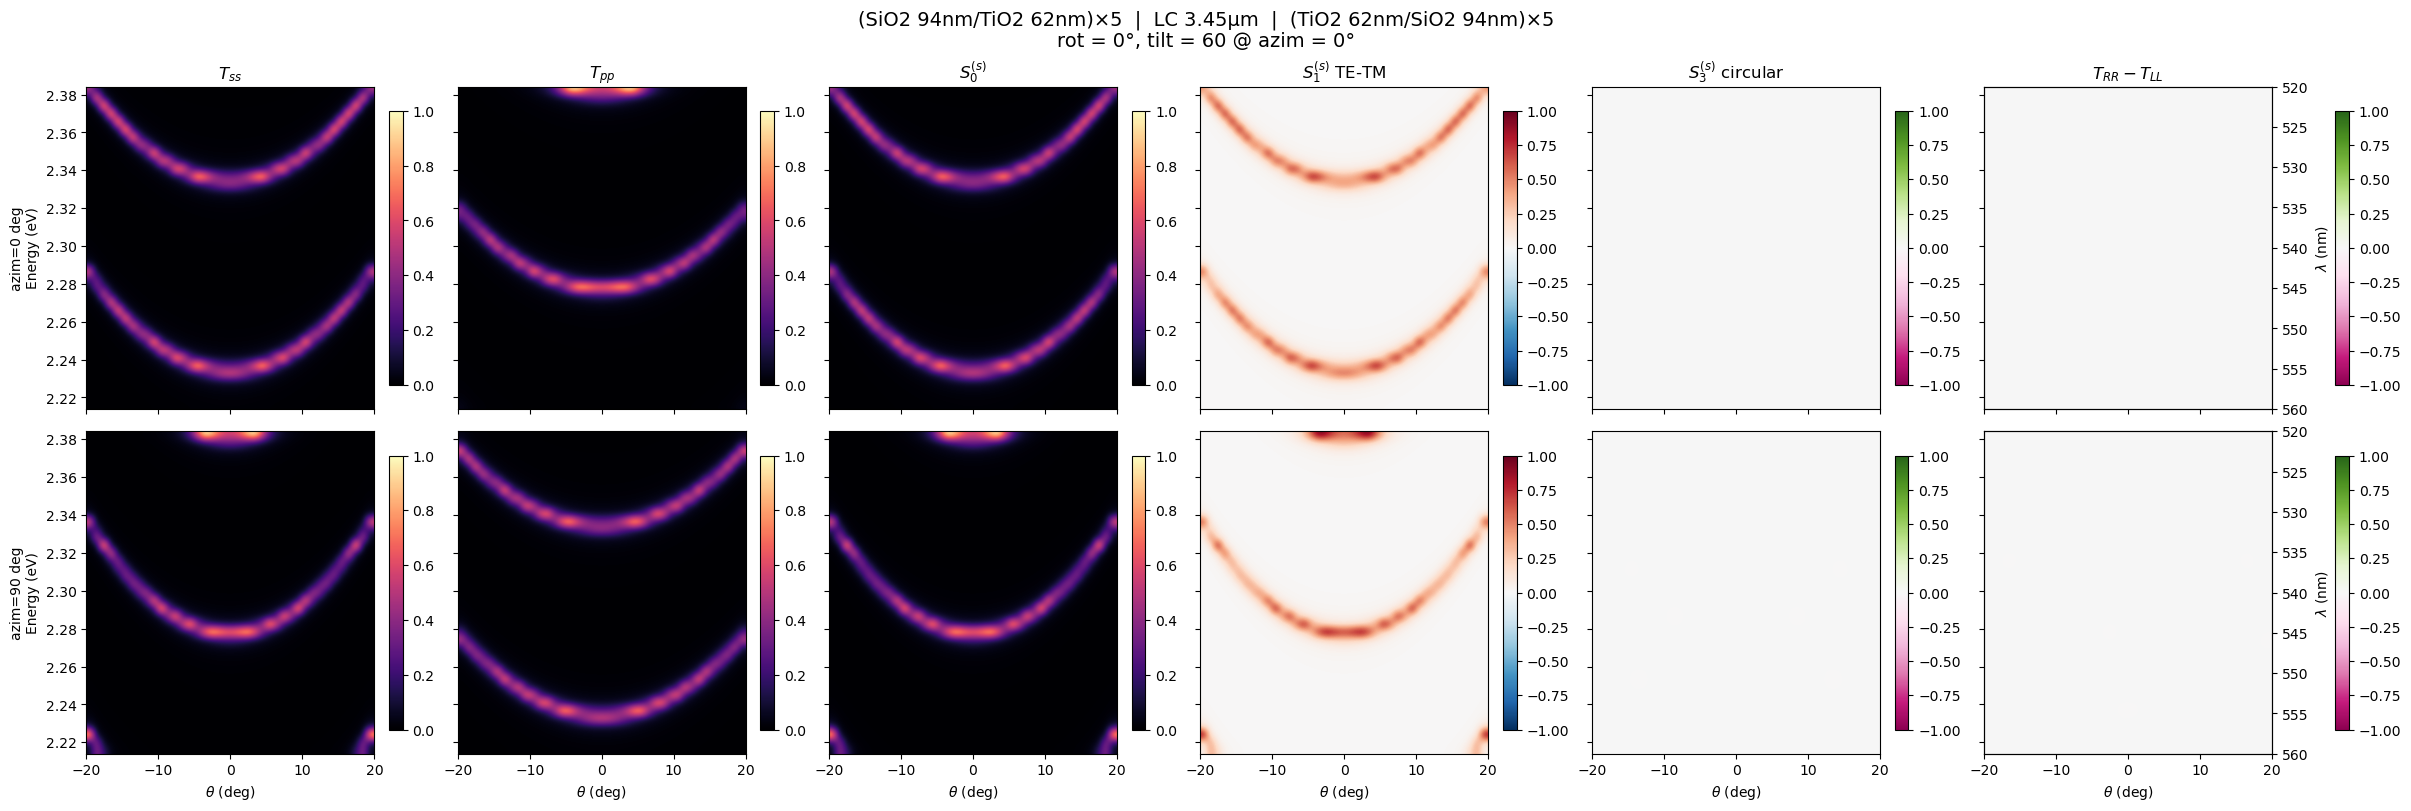

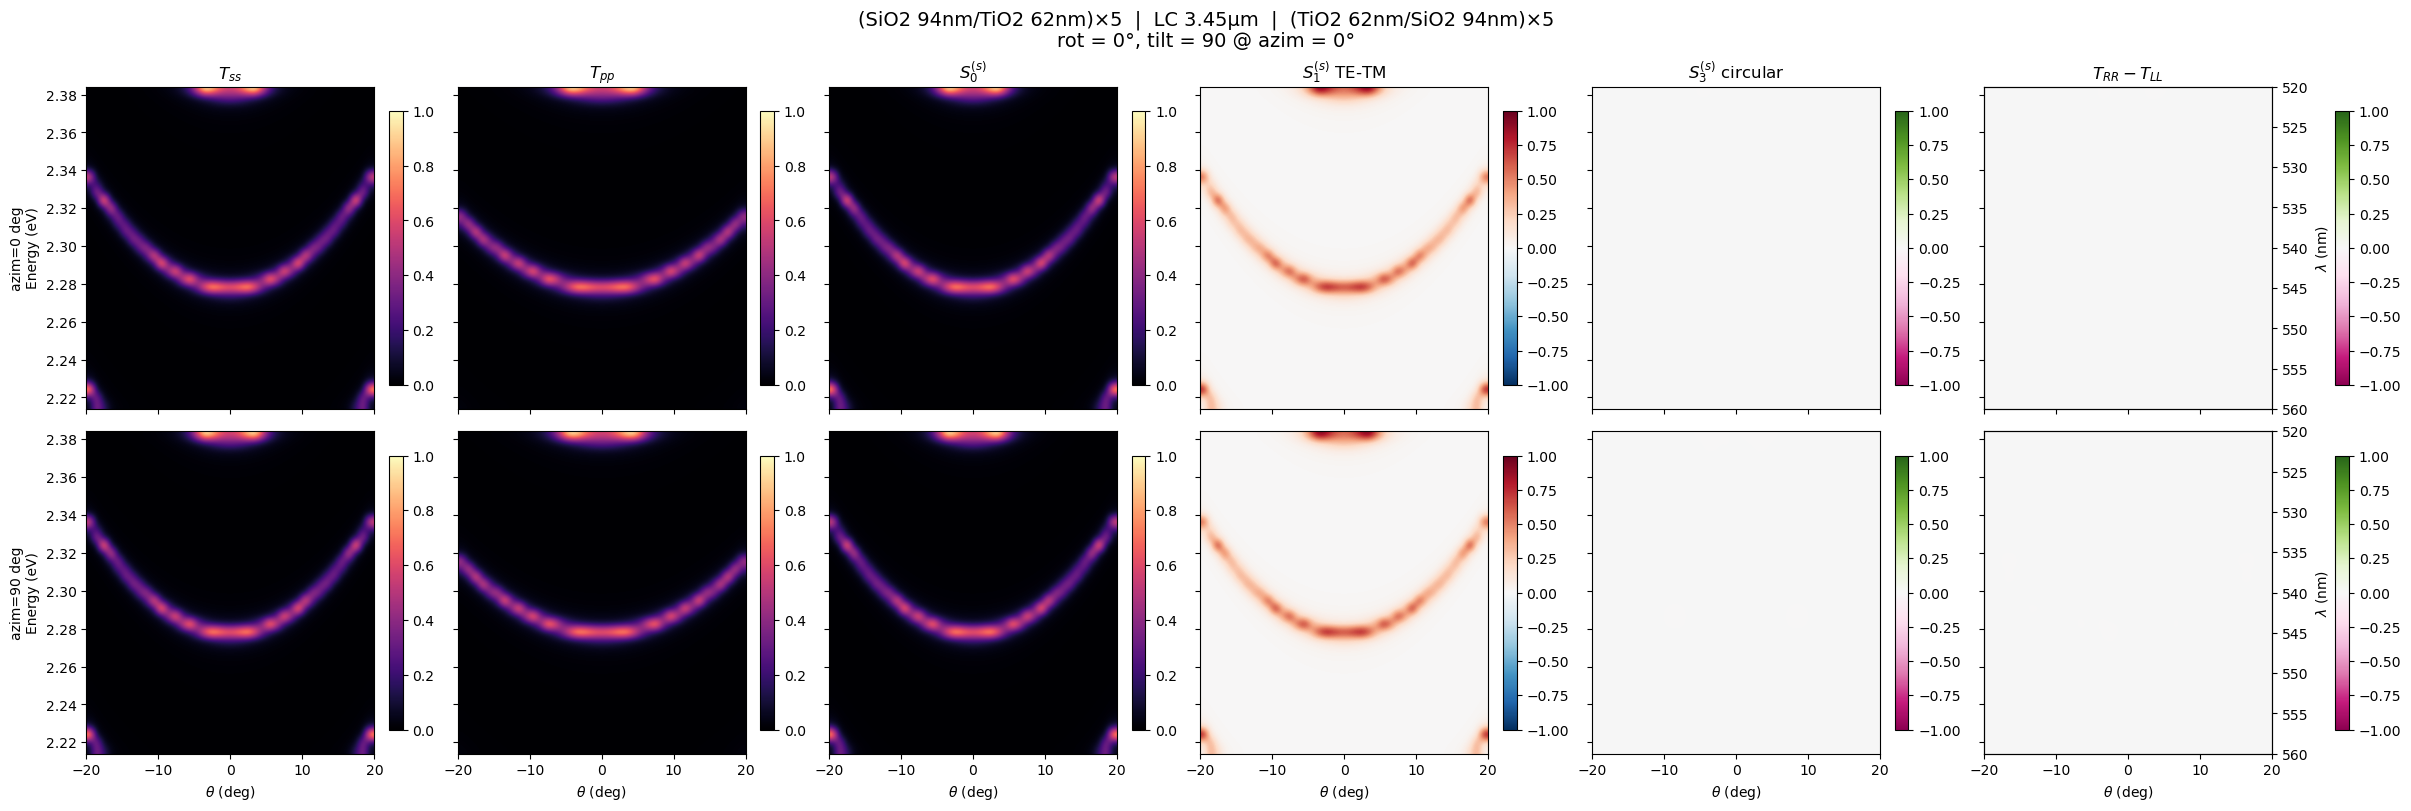

In [10]:
# plot_study1DBR = ru.plot_study1(df_study1_DBR, confLC, tilt_deg=30)
plot_df_study1_LC_0          = ru.plot_study1(df_study1_LC_0,     dataclasses.replace(confLC,       global_tilt = 0, global_tilt_azim = 0       ),      tilt_deg= 0, tilt_azim_deg=0  )
# plot_df_study1_LC_10         = ru.plot_study1(df_study1_LC_10,     dataclasses.replace(confLC,      global_tilt = 10      ),      tilt_deg= 10         )
plot_df_study1_LC_25         = ru.plot_study1(df_study1_LC_25,     dataclasses.replace(confLC,      global_tilt = 25, global_tilt_azim = 0      ),    tilt_deg= 25, tilt_azim_deg=0         )
plot_df_study1_LC_30         = ru.plot_study1(df_study1_LC_30,     dataclasses.replace(confLC,      global_tilt = 30, global_tilt_azim = 0      ),    tilt_deg= 30, tilt_azim_deg=0         )
plot_df_study1_LC_35         = ru.plot_study1(df_study1_LC_35,     dataclasses.replace(confLC,      global_tilt = 35, global_tilt_azim = 0      ),    tilt_deg= 35, tilt_azim_deg=0         )
# plot_df_study1_LC_5115       = ru.plot_study1(df_study1_LC_5115,     dataclasses.replace(confLC,    global_tilt = 51.15   ),      tilt_deg= 51.15      )
plot_df_study1_LC_60         = ru.plot_study1(df_study1_LC_60,     dataclasses.replace(confLC,      global_tilt = 60, global_tilt_azim = 0      ),    tilt_deg= 60, tilt_azim_deg=0         )
# plot_df_study1_LC_6515       = ru.plot_study1(df_study1_LC_6515,     dataclasses.replace(confLC,    global_tilt = 65.15   ),      tilt_deg= 65.15      )
# plot_df_study1_LC_80         = ru.plot_study1(df_study1_LC_80,     dataclasses.replace(confLC,      global_tilt = 80      ),      tilt_deg= 80         )
plot_df_study1_LC_90         = ru.plot_study1(df_study1_LC_90,     dataclasses.replace(confLC,      global_tilt = 90, global_tilt_azim = 0      ),      tilt_deg= 90, tilt_azim_deg=0         )

## Appendix

### Geometry options

| GEOMETRY | Description |
|---|---|
| `'pillar'` | Single square pillar in air background |
| `'hole'` | Single square air hole in slab |
| `'cuboids'` | Two asymmetric square pillars (diagonal arrangement) |

### Material notes
- **CrSBr**: dispersive anisotropic tensor from interpolated n,k data. `PHIZ_VALS` sweeps the b-axis rotation angle.
- **ReS2**: non-dispersive birefringent dielectric. `EPS0` and `DELTA_EPS` set the permittivities directly.

### Key conventions
- s-polarisation = ⊥ plane of incidence (TE in COMSOL, = ŷ at azim=0°, normal incidence)
- p-polarisation = ∥ plane of incidence (TM in COMSOL)
- Circular: R = (s+ip)/√2, L = (s−ip)/√2
- CD = T_RR − T_LL (positive = more right-circular transmitted)
- S3 > 0: right-elliptical output for s-pol input

### S4 API reference
| Call | Purpose |
|---|---|
| `S.SetFrequency(1/lam)` | Set wavelength (lam in same units as lattice) |
| `S.SetMaterial(Name, Epsilon)` | Update material (cheap, reuses geometry) |
| `S.SetExcitationPlanewave(...)` | Set incident field |
| `S.GetFieldsOnGridNumpy(z, (N,N))` | Fast field grid → shape (N,N,3) |
| `S.GetPowerFlux(Layer, zOffset)` | T/R power flux |
| `S.GetBasisSet()` | List of (i,j) G-vectors |
